In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re, string

In [3]:
# === 2. Đọc dữ liệu ===
df_reviews = pd.read_csv("../data/lazada_all_reviews2.csv")
df_products = pd.read_csv("../data/lazada_all_products2.csv")

In [4]:
# --- 3. Gộp 2 bảng lại theo cột "URL" ---
df = pd.merge(df_reviews, df_products[["URL", "Tên sản phẩm"]], on="URL", how="left")

In [5]:
# Làm sạch dữ liệu
df_reviews = df_reviews.dropna(subset=["Nội dung", "Trang"])
df_reviews["Nội dung"] = df_reviews["Nội dung"].astype(str)

In [6]:
# Tổng quan
print("Tổng số đánh giá:", len(df))
print("Số sản phẩm (Trang) khác nhau:", df["Trang"].nunique())
print("Số người đánh giá khác nhau:", df["Tên"].nunique())

Tổng số đánh giá: 11041
Số sản phẩm (Trang) khác nhau: 201
Số người đánh giá khác nhau: 2680


In [7]:
# Xử lý thời gian để phân tích theo tháng ---
df["Thời gian đánh giá"] = pd.to_datetime(df["Thời gian đánh giá"], errors="coerce")
df = df.dropna(subset=["Thời gian đánh giá"])
df["Tháng"] = df["Thời gian đánh giá"].dt.to_period("M").astype(str)

C:\Users\Nhân\AppData\Local\Temp\ipykernel_25516\2720138511.py:9: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Nhân\AppData\Local\Temp\ipykernel_25516\2720138511.py:11: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig("bieudo_theo_thang.png")
C:\Users\Nhân\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


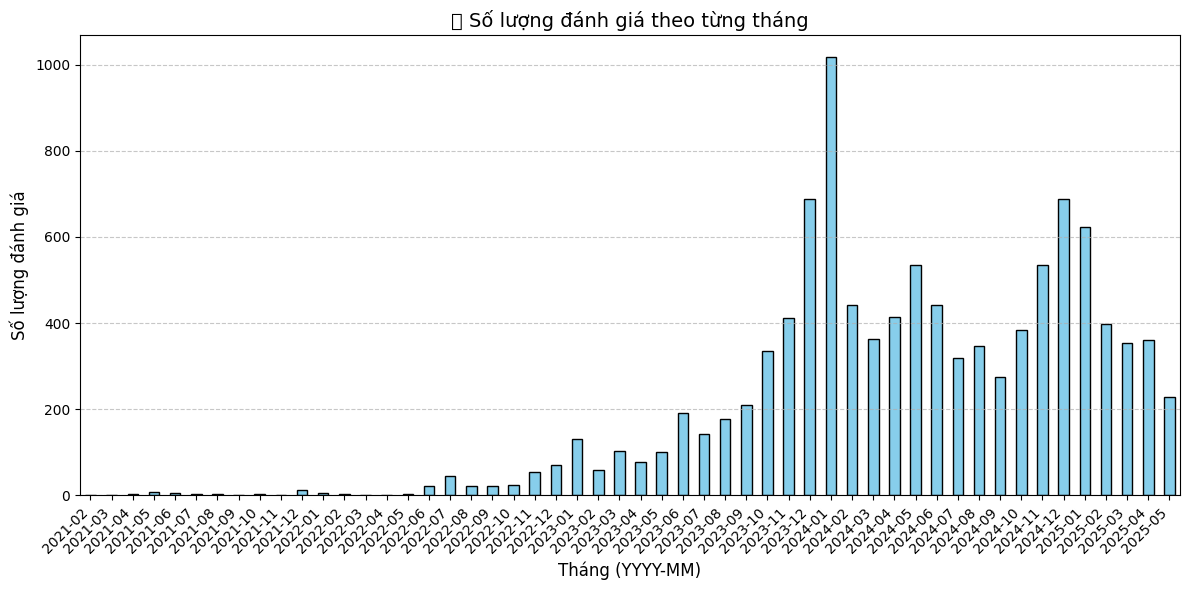

In [8]:
# Biểu đồ số lượng đánh giá theo tháng 
monthly_counts = df["Tháng"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
monthly_counts.plot(kind="bar", color="skyblue", edgecolor='black')
plt.title("📅 Số lượng đánh giá theo từng tháng", fontsize=14)
plt.xlabel("Tháng (YYYY-MM)", fontsize=12)
plt.ylabel("Số lượng đánh giá", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("bieudo_theo_thang.png")
plt.show()

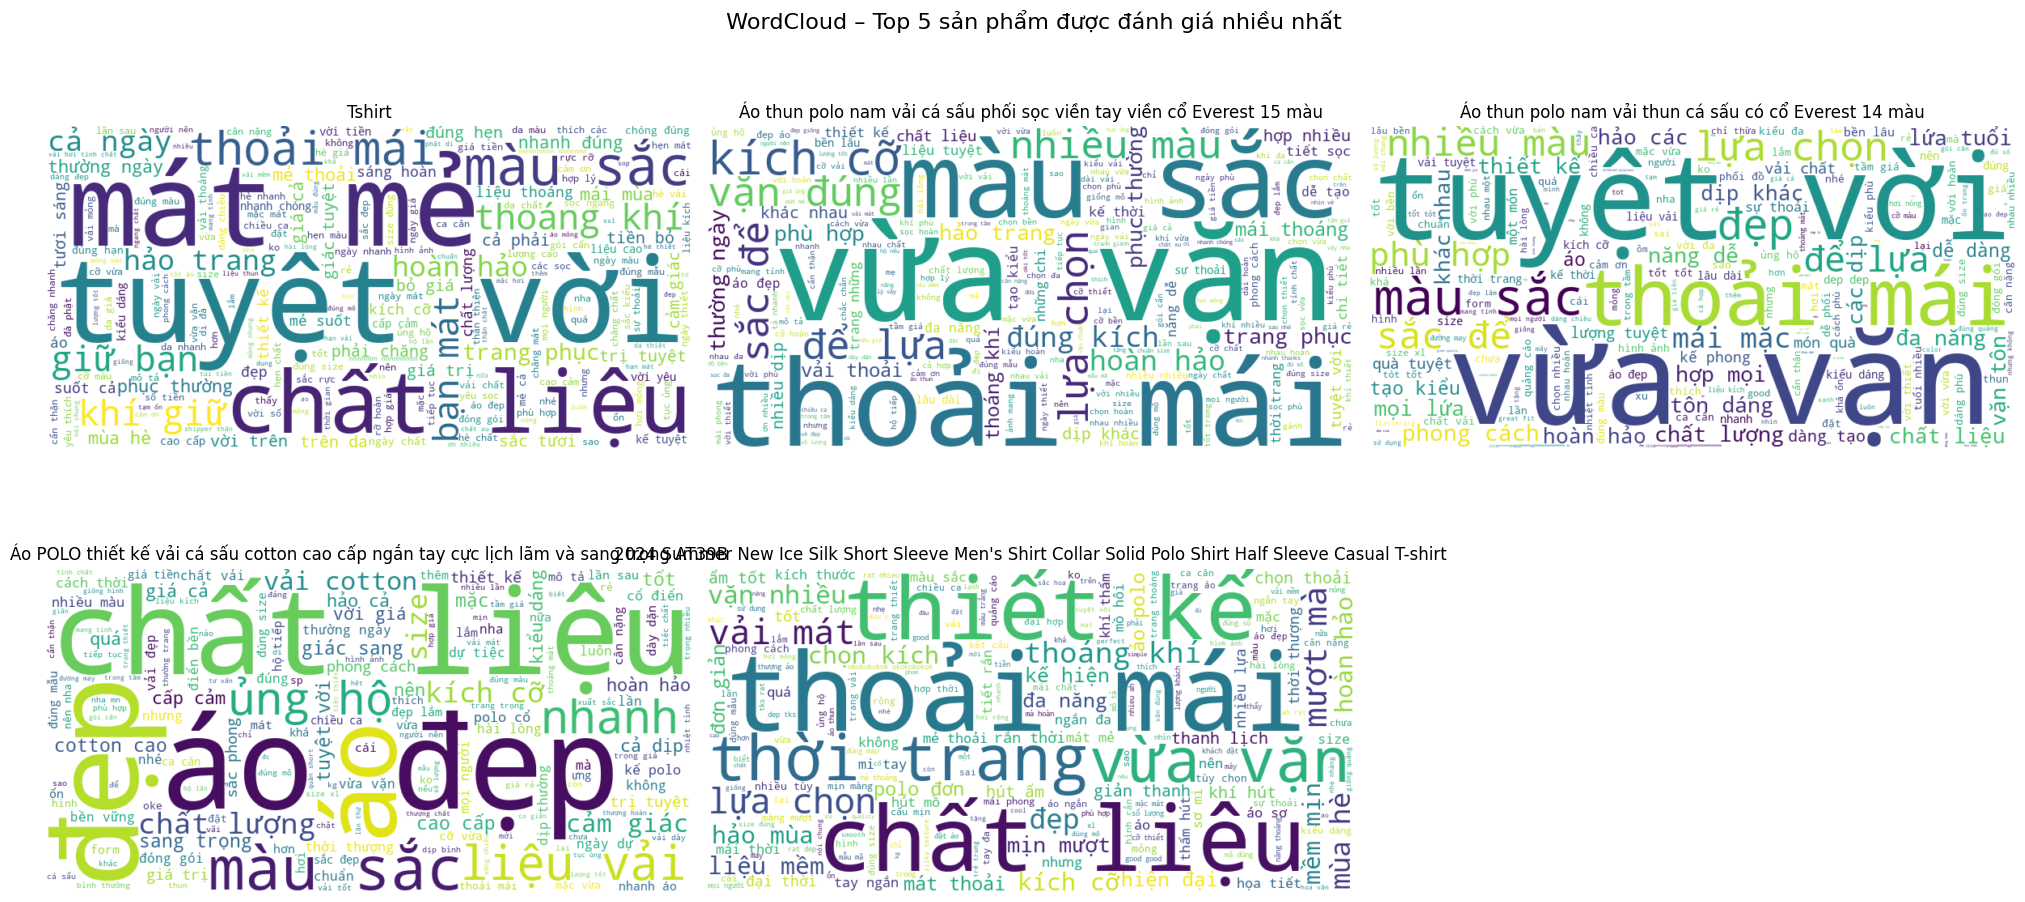

In [10]:
import re
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#  Stopwords và hàm làm sạch văn bản 
stopwords = set([
    "là", "có", "rằng", "và", "cho", "với", "này", "thì", "cũng", "rất", "bị",
    "như", "đã", "của", "ở", "ra", "ok", "gì", "sẽ", "khi", "vì", "em", "anh", "tôi",
    "được", "mình", "shop", "sản", "phẩm", "mua", "giao", "hàng", "rồi", "nhận"
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    words = [w for w in text.split() if w not in stopwords and len(w) > 1]
    return " ".join(words)

#  Top 5 sản phẩm được đánh giá nhiều nhất 
top_products = df["Tên sản phẩm"].value_counts().nlargest(5).index.tolist()

#  Vẽ WordCloud 
plt.figure(figsize=(20, 10))
for i, product in enumerate(top_products):
    subset = df[df["Tên sản phẩm"] == product]
    cleaned = subset["Nội dung"].dropna().apply(clean_text)
    text = " ".join(cleaned)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=200
    ).generate(text)

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(product, fontsize=12)

plt.suptitle(" WordCloud – Top 5 sản phẩm được đánh giá nhiều nhất", fontsize=16)
plt.tight_layout()
plt.savefig("wordcloud_top5_products.png")
plt.show()
